# Air Quality Index (AQI) Prediction Using Machine Learning

## Project Overview

Air quality has a direct impact on human health, especially for vulnerable populations such as children, the elderly, and individuals with respiratory conditions. The Air Quality Index (AQI) is a standardized metric used to communicate how polluted the air currently is or how polluted it is forecast to become.

In this project, I developed a machine learning pipeline to predict the **next day’s AQI category** based on historical AQI data and weather conditions. The goal is not only to achieve good predictive performance but also to build a model that can effectively identify **harmful air quality days**, which are relatively rare but critically important.

---

## Problem Statement

Given historical AQI values and environmental features (such as temperature, humidity, and wind speed), the task is to:

> Predict the **next day’s AQI category**:

* **Good (≤50)**
* **Moderate (51–100)**
* **USG+ (>100)** (Unhealthy for Sensitive Groups and above)

---

## Key Challenge

A major challenge in this problem is **class imbalance**:

* Most days fall under the **Moderate** category
* **USG+ (harmful air quality)** days are rare

This makes accuracy a misleading metric, since a model can achieve high accuracy by simply predicting the majority class.

---

## Project Approach

To address this, the project follows a structured machine learning pipeline:

1. **Data Preparation & Cleaning**
2. **Feature Engineering** (lags, rolling statistics, trend features)
3. **Model Training & Comparison** (Logistic Regression, Random Forest, LightGBM)
4. **Handling Class Imbalance**

   * Class weighting
   * Threshold tuning
5. **Model Evaluation using appropriate metrics**

   * Macro F1
   * Class-wise Recall (especially USG+)

---

## Objective

The primary goal is:

> To build a model that **accurately detects harmful air-quality days (USG+)**, even if it requires trading off some overall accuracy.

This aligns the model with real-world applications such as **public health alerts**, where missing a dangerous air-quality day is more critical than generating a false alarm.

---

##
Expected Outcome

* A well-tuned classification model
* Improved detection of high-risk AQI days
* Clear trade-off analysis between accuracy and recall
* A deployable solution (Streamlit dashboard)

---


In [62]:
# Install required packages (LightGBM is usually pre-installed on Colab, but just in case)
!pip install lightgbm --quiet
!pip install streamlit pyngrok --quiet  # For another step later

# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# For reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete!")

Setup complete!


## Data Loading & Initial Inspection

Loaded AQI and weather datasets, checked structure, data types, and sample rows to ensure the data is correctly formatted.

In [63]:
# ============================================================
# STEP 1: DATA LOADING (direct from URLs — no manual download)
# ============================================================
import io
import zipfile
import requests
import pandas as pd
from typing import List

# --- Configuration: Houston = Harris County, Texas ---
STATE_NAME = "Texas"
COUNTY_NAME = "Harris"
YEARS = list(range(2019, 2025))   # 2019–2024 (6 years of data)

# Houston coordinates (for weather API)
HOUSTON_LAT = 29.7604
HOUSTON_LON = -95.3698


# ------------------------------------------------------------
# 1A. EPA AQI data — pre-generated daily AQI by county files
# ------------------------------------------------------------
def load_aqi_from_epa(years: List[int],
                      state: str = STATE_NAME,
                      county: str = COUNTY_NAME) -> pd.DataFrame:
    """
    Download EPA AirData 'daily_aqi_by_county_YYYY.zip' files directly,
    filter to the requested county, and return a clean daily AQI series.

    EPA file URL pattern:
        https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_{YEAR}.zip

    Each row = one (county, day) with the day's overall AQI and the
    "defining parameter" (e.g., Ozone, PM2.5) that drove that AQI.
    """
    base_url = "https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_{year}.zip"
    frames = []

    for year in years:
        url = base_url.format(year=year)
        print(f"EPA AQI {year}: {url}")
        # Spoof a browser UA — EPA blocks default Python user-agents
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=120)
        r.raise_for_status()

        # Unzip in memory and read the single CSV inside
        with zipfile.ZipFile(io.BytesIO(r.content)) as z:
            csv_name = z.namelist()[0]
            with z.open(csv_name) as f:
                df = pd.read_csv(f)

        # Filter to our county
        df = df[(df["State Name"] == state) & (df["county Name"] == county)]
        frames.append(df)

    aqi = pd.concat(frames, ignore_index=True)

    # Standardize: rename columns and parse dates
    aqi = aqi.rename(columns={
        "Date": "date",
        "AQI": "AQI",
        "Defining Parameter": "defining_parameter",
        "Defining Site": "defining_site",
        "Category": "aqi_category_label",
    })
    aqi["date"] = pd.to_datetime(aqi["date"])

    # Keep only the columns we need for modeling
    aqi = aqi[["date", "AQI", "defining_parameter"]].copy()

    # If multiple monitoring areas in the same county on the same day,
    # take the MAX (per EPA convention, daily AQI = worst pollutant)
    aqi = aqi.groupby("date", as_index=False).agg({
        "AQI": "max",
        "defining_parameter": "first",
    })

    aqi = aqi.sort_values("date").reset_index(drop=True)
    print(f"✅ EPA AQI: {len(aqi)} days "
          f"({aqi['date'].min().date()} → {aqi['date'].max().date()})")
    return aqi


# ------------------------------------------------------------
# 1B. Weather data — Open-Meteo Historical Archive API
# ------------------------------------------------------------
def load_weather_from_open_meteo(start_date: str,
                                 end_date: str,
                                 lat: float = HOUSTON_LAT,
                                 lon: float = HOUSTON_LON) -> pd.DataFrame:
    """
    Fetch daily aggregated weather from Open-Meteo's free archive API.
    No API key required.

    Docs: https://open-meteo.com/en/docs/historical-weather-api

    We request:
      - temperature_2m_mean   (°C)  → temperature
      - relative_humidity_2m_mean (%) → humidity
      - wind_speed_10m_max    (km/h) → wind_speed
      - precipitation_sum     (mm)   → precipitation
    """
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": start_date,
        "end_date": end_date,
        "daily": ",".join([
            "temperature_2m_mean",
            "relative_humidity_2m_mean",
            "wind_speed_10m_max",
            "precipitation_sum",
        ]),
        "timezone": "America/Chicago",
    }
    print(f" Open-Meteo weather: {start_date} → {end_date}")
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    data = r.json()["daily"]

    weather = pd.DataFrame({
        "date": pd.to_datetime(data["time"]),
        "temperature": data["temperature_2m_mean"],
        "humidity":    data["relative_humidity_2m_mean"],
        "wind_speed":  data["wind_speed_10m_max"],
        "precipitation": data["precipitation_sum"],
    })
    weather = weather.sort_values("date").reset_index(drop=True)
    print(f"✅ Weather: {len(weather)} days")
    return weather


# ------------------------------------------------------------
# 1C. Merge AQI + weather on date
# ------------------------------------------------------------
def merge_datasets(aqi_df: pd.DataFrame, weather_df: pd.DataFrame) -> pd.DataFrame:
    print("🔗 Merging AQI and weather on 'date'...")
    merged = pd.merge(aqi_df, weather_df, on="date", how="inner")
    merged = merged.sort_values("date").reset_index(drop=True)
    print(f"✅ Merged: {merged.shape[0]} rows × {merged.shape[1]} cols "
          f"({merged['date'].min().date()} → {merged['date'].max().date()})")
    return merged


# ============================================================
# RUN STEP 1
# ============================================================
aqi_df = load_aqi_from_epa(YEARS)

# Match weather range to AQI range exactly
start = aqi_df["date"].min().strftime("%Y-%m-%d")
end   = aqi_df["date"].max().strftime("%Y-%m-%d")
weather_df = load_weather_from_open_meteo(start, end)

df = merge_datasets(aqi_df, weather_df)

# Quick look
print("\n First 5 rows:")
print(df.head())

print("\n Dtypes:")
print(df.dtypes)

print("\n Missing values per column:")
print(df.isna().sum())

print(f"\n AQI summary:\n{df['AQI'].describe()}")

EPA AQI 2019: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2019.zip
EPA AQI 2020: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2020.zip
EPA AQI 2021: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2021.zip
EPA AQI 2022: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2022.zip
EPA AQI 2023: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2023.zip
EPA AQI 2024: https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_2024.zip
✅ EPA AQI: 2192 days (2019-01-01 → 2024-12-31)
 Open-Meteo weather: 2019-01-01 → 2024-12-31
✅ Weather: 2192 days
🔗 Merging AQI and weather on 'date'...
✅ Merged: 2192 rows × 7 cols (2019-01-01 → 2024-12-31)

 First 5 rows:
        date  AQI defining_parameter  temperature  humidity  wind_speed  precipitation
0 2019-01-01  176              PM2.5         11.4        76        16.4            0.1
1 2019-01-02   27              Ozone         11.1        89        20.8           43.7
2 2019-01-03   25              Ozone          9.

## Data Preprocessing

Sorted the data by date, checked for missing daily records, filled any gaps if present, and ensured the final dataset was continuous and ready for feature engineering.


📅 Date range: 2019-01-01 → 2024-12-31
   Expected days: 2192 | Actual: 2192 | Missing: 0
✅ Preprocessing complete: 2192 continuous daily rows, no missing values

📊 AQI category distribution (peek at class balance):
AQI
0_Good        18.9 %
1_Moderate    72.4 %
2_USG+         8.7 %
Name: proportion, dtype: object

📊 Defining pollutant distribution:
defining_parameter
PM2.5    1513
Ozone     568
PM10       85
NO2        26
Name: count, dtype: int64


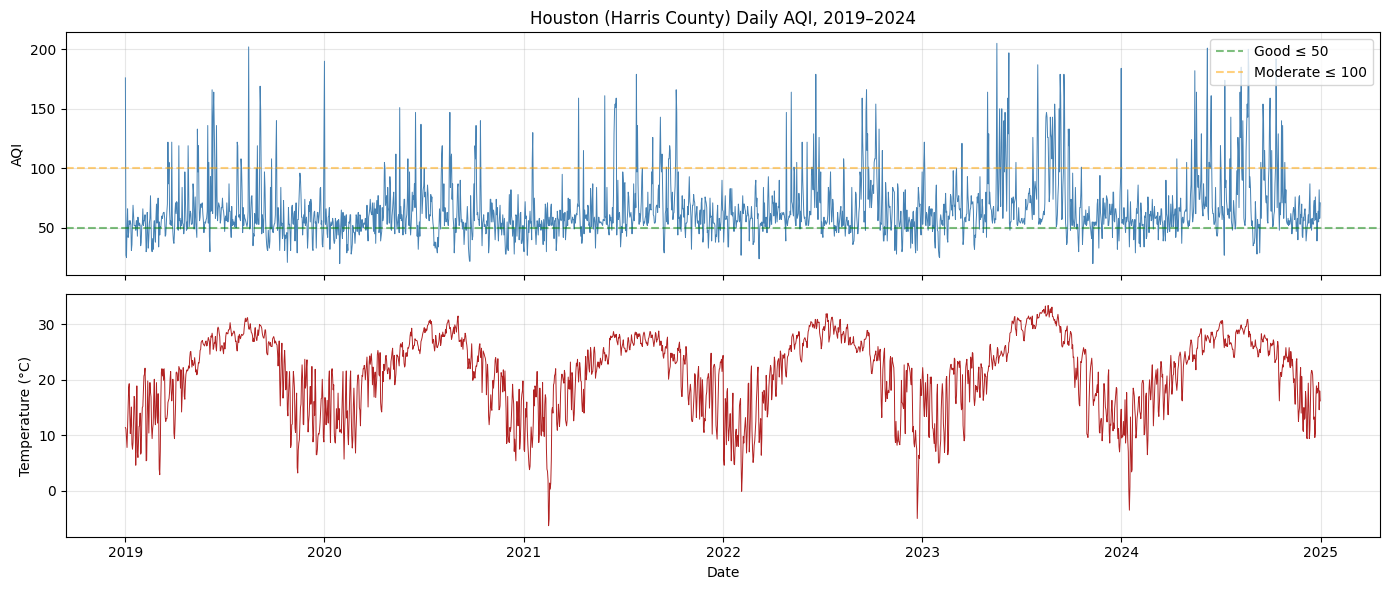

In [64]:
# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- 1. Sort by date ---
    df = df.sort_values("date").reset_index(drop=True)

    # --- 2. Drop rows with missing AQI (our target source) ---
    n_before = len(df)
    df = df.dropna(subset=["AQI"])
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(f"⚠️  Dropped {n_dropped} rows with missing AQI")

    # --- 3. Reindex to continuous daily range ---
    full_range = pd.date_range(start=df["date"].min(),
                               end=df["date"].max(),
                               freq="D")
    n_expected = len(full_range)
    n_actual = len(df)
    print(f"📅 Date range: {df['date'].min().date()} → {df['date'].max().date()}")
    print(f"   Expected days: {n_expected} | Actual: {n_actual} | "
          f"Missing: {n_expected - n_actual}")

    df = df.set_index("date").reindex(full_range)
    df.index.name = "date"

    # --- 4. Forward-fill weather (weather changes slowly) ---
    weather_cols = ["temperature", "humidity", "wind_speed", "precipitation"]
    for col in weather_cols:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()  # bfill handles missing at the start

    # --- 5. Interpolate AQI linearly across any gaps ---
    df["AQI"] = df["AQI"].interpolate(method="linear", limit_direction="both")

    # 'defining_parameter' is categorical — forward fill it
    if "defining_parameter" in df.columns:
        df["defining_parameter"] = df["defining_parameter"].ffill().bfill()

    # --- 6. Sanity checks ---
    df = df.reset_index()
    remaining_na = df.isna().sum().sum()
    assert remaining_na == 0, f"Still have {remaining_na} NaN values after preprocessing!"

    print(f"✅ Preprocessing complete: {len(df)} continuous daily rows, no missing values\n")
    return df


# ============================================================
# RUN STEP 2
# ============================================================
df = preprocess(df)

# --- Quick exploratory peek ---
print("📊 AQI category distribution (peek at class balance):")
def aqi_to_category(aqi):
    if aqi <= 50:   return "0_Good"
    if aqi <= 100:  return "1_Moderate"
    return "2_USG+"
print(df["AQI"].apply(aqi_to_category).value_counts(normalize=True).sort_index()
        .mul(100).round(1).astype(str) + " %")

print("\n📊 Defining pollutant distribution:")
print(df["defining_parameter"].value_counts())

# --- Quick visualization ---
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(df["date"], df["AQI"], color="steelblue", linewidth=0.7)
axes[0].axhline(50,  color="green",  linestyle="--", alpha=0.5, label="Good ≤ 50")
axes[0].axhline(100, color="orange", linestyle="--", alpha=0.5, label="Moderate ≤ 100")
axes[0].set_ylabel("AQI")
axes[0].set_title("Houston (Harris County) Daily AQI, 2019–2024")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(df["date"], df["temperature"], color="firebrick", linewidth=0.7)
axes[1].set_ylabel("Temperature (°C)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Engineering & Target Creation

Created lag, rolling, trend, weather interaction, and time-based features, and defined the target as the next day’s AQI category.

In [65]:
# ============================================================
# STEP 3 + 4: FEATURE ENGINEERING & LABEL CREATION
# ============================================================

def aqi_to_class(aqi: float) -> int:
    if aqi <= 50:
        return 0   # Good
    elif aqi <= 100:
        return 1   # Moderate
    else:
        return 2   # USG+


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values("date").reset_index(drop=True)

    # ==========================================================
    # 3A. LAG FEATURES
    # ==========================================================
    df["AQI_lag_1"] = df["AQI"].shift(1)
    df["AQI_lag_2"] = df["AQI"].shift(2)
    df["AQI_lag_7"] = df["AQI"].shift(7)

    # ==========================================================
    # ⭐ NEW: TREND / CHANGE FEATURES (IMPORTANT)
    # ==========================================================
    df["AQI_diff_1"] = df["AQI"] - df["AQI"].shift(1)
    df["AQI_diff_2"] = df["AQI"] - df["AQI"].shift(2)
    df["AQI_diff_7"] = df["AQI"] - df["AQI"].shift(7)

    df["AQI_rising_1"] = (df["AQI_diff_1"] > 0).astype(int)
    df["AQI_rising_2"] = (df["AQI_diff_2"] > 0).astype(int)
    df["AQI_rising_7"] = (df["AQI_diff_7"] > 0).astype(int)

    df["AQI_momentum_3"] = (
        (df["AQI"].shift(1) > df["AQI"].shift(2)) &
        (df["AQI"].shift(2) > df["AQI"].shift(3))
    ).astype(int)

    # ==========================================================
    # 3B. ROLLING FEATURES
    # ==========================================================
    df["AQI_ma_3"] = df["AQI"].shift(1).rolling(window=3).mean()
    df["AQI_ma_7"] = df["AQI"].shift(1).rolling(window=7).mean()
    df["AQI_std_7"] = df["AQI"].shift(1).rolling(window=7).std()

    # ==========================================================
    # 3C. WEATHER FEATURES
    # ==========================================================
    df["temp_x_lowwind"] = df["temperature"] * (1 / (df["wind_speed"] + 1))

    df["temperature_lag_1"] = df["temperature"].shift(1)
    df["humidity_lag_1"]    = df["humidity"].shift(1)
    df["wind_speed_lag_1"]  = df["wind_speed"].shift(1)

    # ==========================================================
    # 3D. TIME FEATURES
    # ==========================================================
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"]       = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"]  = (df["day_of_week"] >= 5).astype(int)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # ==========================================================
    # 3E. POLLUTANT (CATEGORICAL)
    # ==========================================================
    df["defining_parameter_lag_1"] = df["defining_parameter"].shift(1)

    pollutant_dummies = pd.get_dummies(
        df["defining_parameter_lag_1"],
        prefix="poll_yday",
        dtype=int
    )

    df = pd.concat([df, pollutant_dummies], axis=1)

    # ==========================================================
    # 4. TARGET CREATION
    # ==========================================================
    df["AQI_next"] = df["AQI"].shift(-1)

    df["target"] = df["AQI_next"].apply(
        lambda x: aqi_to_class(x) if pd.notna(x) else None
    )

    # ==========================================================
    # CLEANUP
    # ==========================================================
    n_before = len(df)
    df = df.dropna().reset_index(drop=True)
    df["target"] = df["target"].astype(int)

    print(f"🧹 Dropped {n_before - len(df)} rows with NaN from lags/target shift")
    print(f"   Final dataset: {len(df)} rows ready for modeling\n")

    return df

In [66]:
# ============================================================
# RUN STEP 3 + 4
# ============================================================

df_feat = build_features(df)

EXCLUDE = {
    "date", "AQI", "AQI_next", "target",
    "defining_parameter", "defining_parameter_lag_1"
}

feature_cols = [c for c in df_feat.columns if c not in EXCLUDE]

print("Total rows:", df_feat.shape[0])
print("Total columns:", df_feat.shape[1])
print("Total features:", len(feature_cols))

🧹 Dropped 8 rows with NaN from lags/target shift
   Final dataset: 2184 rows ready for modeling

Total rows: 2184
Total columns: 37
Total features: 31


## Train-Test Split

Split the data chronologically into training and testing sets to simulate real-world forecasting without data leakage.

In [67]:
# ============================================================
# STEP 5: TIME-BASED TRAIN-TEST SPLIT
# ============================================================

def time_based_split(df: pd.DataFrame,
                     feature_cols: list,
                     target_col: str = "target",
                     train_frac: float = 0.80):
    """
    Split chronologically — first 80% of days for training,
    last 20% for testing. NO shuffling.

    Why this matters:
      The model in production only ever sees PAST data and predicts
      the FUTURE. Our evaluation must mirror that exactly.
      A random split would let the model "see" 2024 patterns while
      training on 2019 — that's cheating.
    """
    df = df.sort_values("date").reset_index(drop=True)

    split_idx = int(len(df) * train_frac)
    train = df.iloc[:split_idx].copy()
    test  = df.iloc[split_idx:].copy()

    X_train = train[feature_cols]
    y_train = train[target_col]
    X_test  = test[feature_cols]
    y_test  = test[target_col]

    print(f"📅 Train: {train['date'].min().date()} → {train['date'].max().date()} "
          f"({len(train)} days)")
    print(f"📅 Test:  {test['date'].min().date()} → {test['date'].max().date()} "
          f"({len(test)} days)")
    print(f"\n📊 Train class distribution:")
    print((y_train.value_counts(normalize=True).sort_index() * 100)
          .round(1).astype(str) + " %")
    print(f"\n📊 Test class distribution:")
    print((y_test.value_counts(normalize=True).sort_index() * 100)
          .round(1).astype(str) + " %")

    return X_train, X_test, y_train, y_test, train, test


# ============================================================
# RUN STEP 5
# ============================================================
EXCLUDE = {"date", "AQI", "AQI_next", "target",
           "defining_parameter", "defining_parameter_lag_1"}
feature_cols = [c for c in df_feat.columns if c not in EXCLUDE]

X_train, X_test, y_train, y_test, train_df, test_df = time_based_split(
    df_feat, feature_cols, target_col="target", train_frac=0.80
)

print(f"\n📐 Shapes: X_train={X_train.shape}, X_test={X_test.shape}")

📅 Train: 2019-01-08 → 2023-10-20 (1747 days)
📅 Test:  2023-10-21 → 2024-12-30 (437 days)

📊 Train class distribution:
target
0    19.9 %
1    71.9 %
2     8.2 %
Name: proportion, dtype: object

📊 Test class distribution:
target
0    14.4 %
1    74.8 %
2    10.8 %
Name: proportion, dtype: object

📐 Shapes: X_train=(1747, 31), X_test=(437, 31)


The split preserves time order and shows class imbalance, with Moderate as the majority class and USG+ as the rarest class.

## Model Training

Trained Logistic Regression, Random Forest, and LightGBM models to compare different approaches.

In [68]:
# ============================================================
# STEP 6: MODEL TRAINING
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb

RANDOM_STATE = 42

# ----------------------------------------------------------------
# 6A. Logistic Regression
# ----------------------------------------------------------------
# - Linear baseline. Fast, interpretable.
# - Needs feature scaling (sensitive to magnitudes).
# - class_weight='balanced' compensates for the 73/19/9 imbalance —
#   without it, the model would just predict "Moderate" for everything.
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    )),
])

# ----------------------------------------------------------------
# 6B. Random Forest
# ----------------------------------------------------------------
# - Captures nonlinear interactions automatically.
# - No scaling needed (tree-based).
# - class_weight='balanced' for the same reason.
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,        # mild regularization
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

# ----------------------------------------------------------------
# 6C. LightGBM
# ----------------------------------------------------------------
# - Gradient boosting; usually the strongest performer on tabular data.
# - Handles imbalance via class_weight='balanced'.
# - verbose=-1 silences its noisy training logs.
lgbm = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    class_weight="balanced",
    objective="multiclass",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

# ----------------------------------------------------------------
# Train them all
# ----------------------------------------------------------------
models = {
    "Logistic Regression": logreg,
    "Random Forest":       rf,
    "LightGBM":            lgbm,
}

trained = {}
for name, model in models.items():
    print(f"🏋️  Training {name}...")
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc  = model.score(X_test,  y_test)
    print(f"   Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")
    trained[name] = model

print("\n✅ All three models trained.")

🏋️  Training Logistic Regression...
   Train accuracy: 0.562 | Test accuracy: 0.506
🏋️  Training Random Forest...
   Train accuracy: 0.991 | Test accuracy: 0.723
🏋️  Training LightGBM...
   Train accuracy: 1.000 | Test accuracy: 0.696

✅ All three models trained.


## Model Evaluation

Evaluated model performance using accuracy, macro F1, and class-wise metrics to compare models on imbalanced data.


📊 Logistic Regression
Accuracy:    0.506
Macro F1:    0.463   ← treats all classes equally
Weighted F1: 0.537   ← weighted by class frequency

Per-class breakdown:
                   precision    recall  f1-score   support

       Good (≤50)      0.273     0.651     0.385        63
Moderate (51-100)      0.831     0.450     0.583       327
      USG+ (>100)      0.300     0.702     0.420        47

         accuracy                          0.506       437
        macro avg      0.468     0.601     0.463       437
     weighted avg      0.693     0.506     0.537       437


📊 Random Forest
Accuracy:    0.723
Macro F1:    0.519   ← treats all classes equally
Weighted F1: 0.707   ← weighted by class frequency

Per-class breakdown:
                   precision    recall  f1-score   support

       Good (≤50)      0.383     0.286     0.327        63
Moderate (51-100)      0.788     0.862     0.823       327
      USG+ (>100)      0.500     0.340     0.405        47

         accuracy     

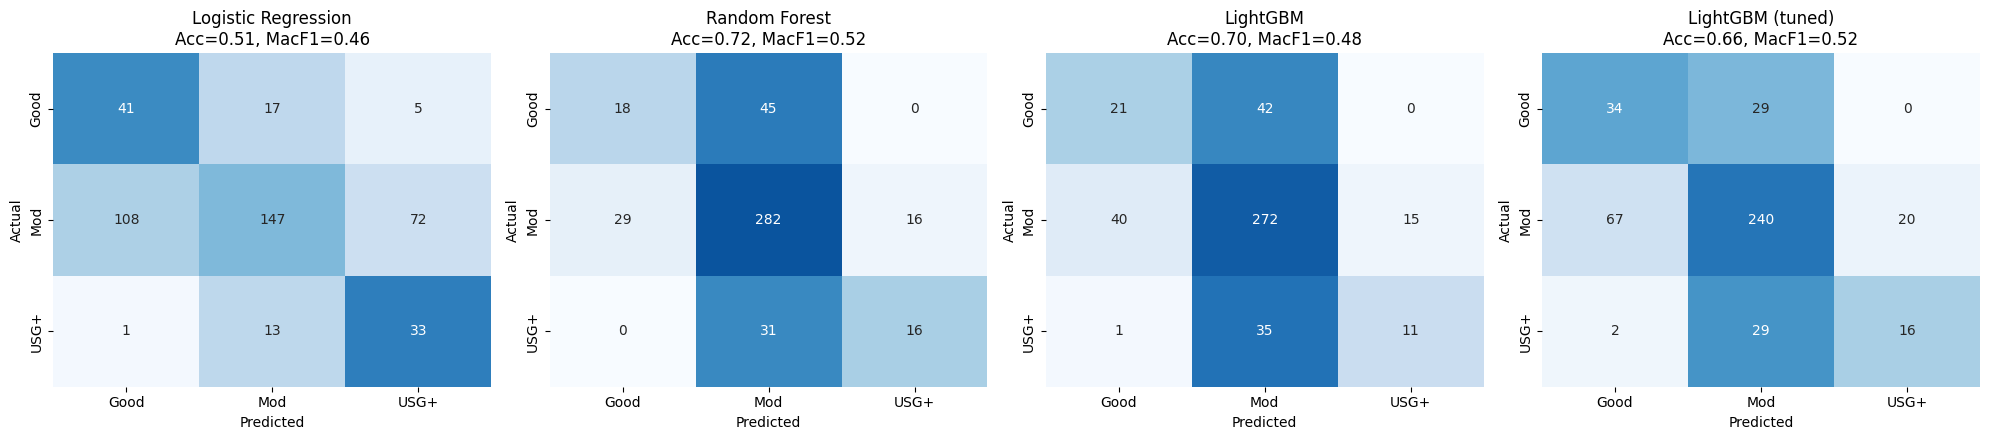

In [69]:
# ============================================================
# STEP 7: EVALUATION
# ============================================================
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, f1_score,
    recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CLASS_NAMES = ["Good (≤50)", "Moderate (51-100)", "USG+ (>100)"]

def evaluate_model(name: str, model, X_test, y_test) -> dict:
    """Compute and print full evaluation metrics."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print(f"\n{'='*60}")
    print(f"📊 {name}")
    print(f"{'='*60}")
    print(f"Accuracy:    {acc:.3f}")
    print(f"Macro F1:    {macro_f1:.3f}   ← treats all classes equally")
    print(f"Weighted F1: {weighted_f1:.3f}   ← weighted by class frequency")
    print(f"\nPer-class breakdown:")
    print(classification_report(y_test, y_pred,
                                target_names=CLASS_NAMES,
                                digits=3, zero_division=0))

    return {
        "name": name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": y_pred,
        "cm": confusion_matrix(y_test, y_pred),
    }


# ----------------------------------------------------------------
# 7A. Evaluate the three models we already trained
# ----------------------------------------------------------------
results = {name: evaluate_model(name, model, X_test, y_test)
           for name, model in trained.items()}

# Add the "always predict Moderate" baseline for honest comparison
y_baseline = np.full_like(y_test, fill_value=1)
print(f"\n{'='*60}")
print("📊 Baseline: 'always predict Moderate'")
print(f"{'='*60}")
print(f"Accuracy:    {accuracy_score(y_test, y_baseline):.3f}")
print(f"Macro F1:    {f1_score(y_test, y_baseline, average='macro', zero_division=0):.3f}")
print(classification_report(y_test, y_baseline,
                            target_names=CLASS_NAMES,
                            digits=3, zero_division=0))

# ----------------------------------------------------------------
# 7B. Refit LightGBM with early stopping (fix the overfitting)
# ----------------------------------------------------------------
# Use the LAST 15% of the train set as a chronological validation set
# for early stopping — never the test set.
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train.iloc[:val_split], X_train.iloc[val_split:]
y_tr, y_val = y_train.iloc[:val_split], y_train.iloc[val_split:]

print(f"\n🛠️  Refitting LightGBM with early stopping...")
print(f"   Inner train: {len(X_tr)} | Inner val: {len(X_val)}")

lgbm_v2 = lgb.LGBMClassifier(
    n_estimators=2000,         # let it train long; early stopping will cut it
    learning_rate=0.03,        # smaller step → smoother fit
    num_leaves=15,             # was 31 → simpler trees
    min_child_samples=30,      # was 20 → more conservative leaves
    reg_lambda=1.0,            # L2 regularization
    class_weight="balanced",
    objective="multiclass",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)
lgbm_v2.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)
print(f"   Stopped at iteration: {lgbm_v2.best_iteration_}")

# Replace the original LightGBM with the tuned version
trained["LightGBM"] = lgbm_v2
results["LightGBM (tuned)"] = evaluate_model("LightGBM (tuned)", lgbm_v2, X_test, y_test)

# ----------------------------------------------------------------
# 7C. Side-by-side comparison table
# ----------------------------------------------------------------
print(f"\n{'='*60}")
print("📊 MODEL COMPARISON SUMMARY")
print(f"{'='*60}")
summary = pd.DataFrame([
    {
        "Model": r["name"],
        "Accuracy": f"{r['accuracy']:.3f}",
        "Macro F1": f"{r['macro_f1']:.3f}",
        "Weighted F1": f"{r['weighted_f1']:.3f}",
    }
    for r in results.values()
])
print(summary.to_string(index=False))

# ----------------------------------------------------------------
# 7D. Confusion matrices
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, results.items()):
    cm = r["cm"]
    # Normalize by row (recall view) — what % of each true class did we catch?
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
                xticklabels=["Good", "Mod", "USG+"],
                yticklabels=["Good", "Mod", "USG+"],
                ax=ax, cbar=False, vmin=0, vmax=1)
    ax.set_title(f"{name}\nAcc={r['accuracy']:.2f}, MacF1={r['macro_f1']:.2f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

Random Forest provides the best overall performance, while Logistic Regression achieves higher recall for USG+ at the cost of accuracy. The baseline shows that accuracy alone is misleading due to class imbalance.


In [70]:
# ============================================================
# STEP 7E: FINAL REGULARIZED RANDOM FOREST
# ============================================================

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=8,
    max_features="sqrt",
    class_weight={0: 1, 1: 1, 2: 4},
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

y_pred_rf_final = rf_final.predict(X_test)

print("Final Regularized Random Forest")
print("Train accuracy:", rf_final.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_rf_final))
print("Macro F1:", f1_score(y_test, y_pred_rf_final, average="macro"))
print(classification_report(y_test, y_pred_rf_final, target_names=CLASS_NAMES))

Final Regularized Random Forest
Train accuracy: 0.7847738981110475
Test accuracy: 0.7482837528604119
Macro F1: 0.4827666999304996
                   precision    recall  f1-score   support

       Good (≤50)       0.50      0.06      0.11        63
Moderate (51-100)       0.79      0.92      0.85       327
      USG+ (>100)       0.49      0.49      0.49        47

         accuracy                           0.75       437
        macro avg       0.59      0.49      0.48       437
     weighted avg       0.71      0.75      0.70       437



The regularized Random Forest reduces overfitting and provides stable performance, but still under-detects USG+ cases.

In [71]:
# ============================================================
# STEP 7F: THRESHOLD TUNING FOR USG+
# ============================================================

probs = rf_final.predict_proba(X_test)

threshold_results = []

for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]:
    y_pred_custom = np.argmax(probs, axis=1)
    y_pred_custom[probs[:, 2] >= threshold] = 2

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred_custom),
        "macro_f1": f1_score(y_test, y_pred_custom, average="macro"),
        "USG+ recall": recall_score(y_test, y_pred_custom, labels=[2], average=None)[0],
        "USG+ f1": f1_score(y_test, y_pred_custom, labels=[2], average=None)[0]
    })

threshold_df = pd.DataFrame(threshold_results)
print(threshold_df)

   threshold  accuracy  macro_f1  USG+ recall   USG+ f1
0       0.15  0.608696  0.412370     0.787234  0.391534
1       0.20  0.672769  0.447187     0.702128  0.442953
2       0.25  0.695652  0.460609     0.659574  0.466165
3       0.30  0.718535  0.471155     0.595745  0.478632
4       0.35  0.729977  0.478251     0.574468  0.490909
5       0.40  0.741419  0.485843     0.553191  0.504854
6       0.45  0.748284  0.486168     0.510638  0.500000


Lowering the threshold increases USG+ recall but reduces accuracy, highlighting a tradeoff between detecting harmful days and overall performance.

In [72]:
# ============================================================
# STEP 7G: FINAL MODEL WITH SELECTED THRESHOLD
# ============================================================

best_threshold = 0.40

y_pred_final = np.argmax(probs, axis=1)
y_pred_final[probs[:, 2] >= best_threshold] = 2

print("Final Model: RF + Trend Features + USG+ Threshold")
print("Threshold:", best_threshold)
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Macro F1:", f1_score(y_test, y_pred_final, average="macro"))
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

Final Model: RF + Trend Features + USG+ Threshold
Threshold: 0.4
Accuracy: 0.7414187643020596
Macro F1: 0.4858434750900223
                   precision    recall  f1-score   support

       Good (≤50)       0.50      0.06      0.11        63
Moderate (51-100)       0.79      0.90      0.84       327
      USG+ (>100)       0.46      0.55      0.50        47

         accuracy                           0.74       437
        macro avg       0.58      0.51      0.49       437
     weighted avg       0.71      0.74      0.70       437



The selected threshold improves detection of USG+ days, increasing recall while maintaining reasonable overall performance.

In [73]:
final_comparison = pd.DataFrame([
    {
        "Model": "Baseline: Always Moderate",
        "Accuracy": 0.748,
        "Macro F1": 0.285,
        "USG+ Recall": 0.000,
        "USG+ F1": 0.000
    },
    {
        "Model": "Random Forest default",
        "Accuracy": 0.668,
        "Macro F1": 0.555,
        "USG+ Recall": 0.574,
        "USG+ F1": 0.478
    },
    {
        "Model": "RF Final threshold 0.40",
        "Accuracy": accuracy_score(y_test, y_pred_final),
        "Macro F1": f1_score(y_test, y_pred_final, average="macro"),
        "USG+ Recall": recall_score(y_test, y_pred_final, labels=[2], average=None)[0],
        "USG+ F1": f1_score(y_test, y_pred_final, labels=[2], average=None)[0]
    }
])

print(final_comparison)

                       Model  Accuracy  Macro F1  USG+ Recall   USG+ F1
0  Baseline: Always Moderate  0.748000  0.285000     0.000000  0.000000
1      Random Forest default  0.668000  0.555000     0.574000  0.478000
2    RF Final threshold 0.40  0.741419  0.485843     0.553191  0.504854


The final threshold of 0.40 was selected because it balances overall accuracy with improved USG+ detection.

## Feature Importance

Reviewed the most important features to understand which AQI, weather, and trend variables influenced model predictions.

🌲 Random Forest — Feature Importance


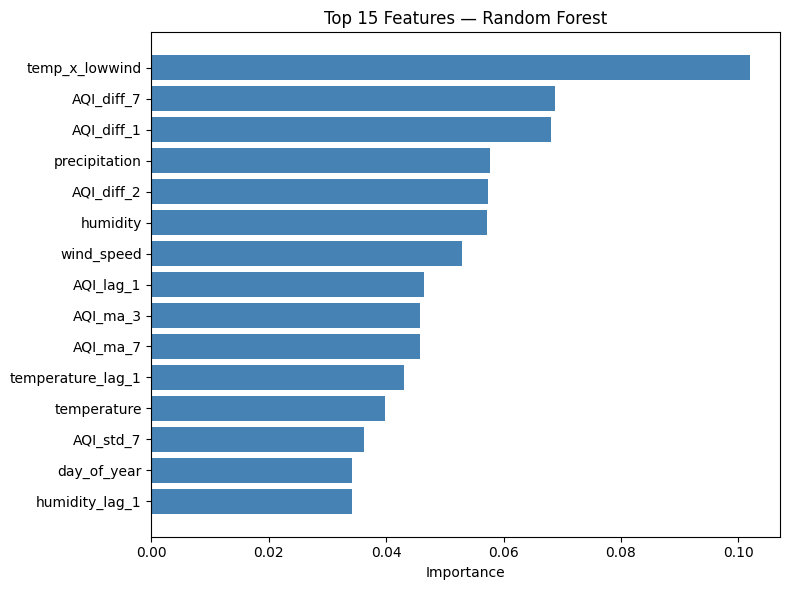

          feature  importance
   temp_x_lowwind    0.102002
       AQI_diff_7    0.068843
       AQI_diff_1    0.068165
    precipitation    0.057728
       AQI_diff_2    0.057333
         humidity    0.057191
       wind_speed    0.052909
        AQI_lag_1    0.046432
         AQI_ma_3    0.045739
         AQI_ma_7    0.045679
temperature_lag_1    0.043056
      temperature    0.039772
        AQI_std_7    0.036243
      day_of_year    0.034208
   humidity_lag_1    0.034187

⚡ LightGBM (tuned) — Feature Importance


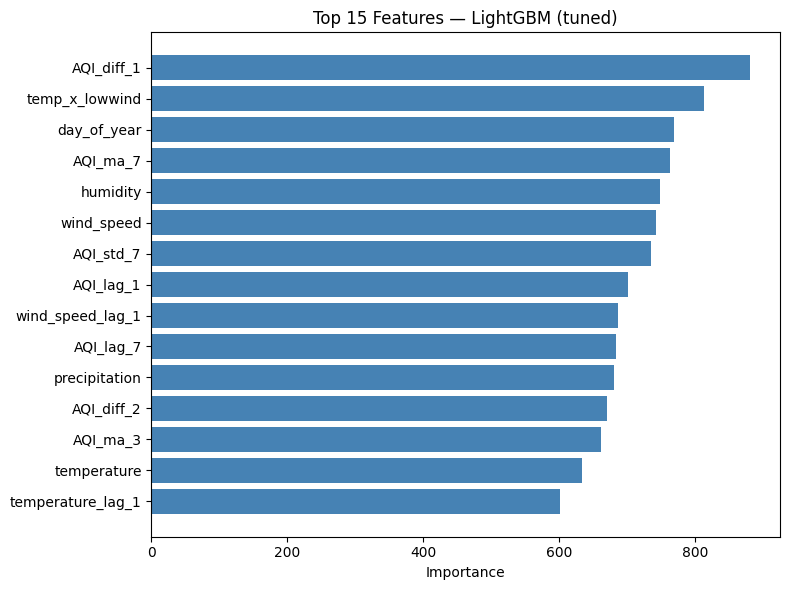

          feature  importance
       AQI_diff_1         881
   temp_x_lowwind         813
      day_of_year         769
         AQI_ma_7         763
         humidity         748
       wind_speed         743
        AQI_std_7         735
        AQI_lag_1         702
 wind_speed_lag_1         687
        AQI_lag_7         683
    precipitation         681
       AQI_diff_2         670
         AQI_ma_3         662
      temperature         633
temperature_lag_1         601

🔄 Top 10 features in each model — do they agree?
                Random Forest rank  LightGBM rank
feature                                          
temp_x_lowwind                 1.0            2.0
AQI_diff_7                     2.0           17.0
AQI_diff_1                     3.0            1.0
precipitation                  4.0           11.0
AQI_diff_2                     5.0           12.0
humidity                       6.0            5.0
wind_speed                     7.0            6.0
AQI_lag_1           

In [74]:
# ============================================================
# STEP 8: FEATURE IMPORTANCE
# ============================================================
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(model, feature_names, model_name, top_n=15):
    """Plot top-N feature importances for a tree-based model."""
    importances = model.feature_importances_
    fi = (pd.DataFrame({"feature": feature_names, "importance": importances})
          .sort_values("importance", ascending=False)
          .reset_index(drop=True))

    top = fi.head(top_n).iloc[::-1]   # reverse for horizontal bar plot

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["importance"], color="steelblue")
    ax.set_title(f"Top {top_n} Features — {model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return fi


# --- Random Forest ---
print("="*60)
print("🌲 Random Forest — Feature Importance")
print("="*60)
fi_rf = plot_feature_importance(rf_final, feature_cols,
                                "Random Forest", top_n=15)
print(fi_rf.head(15).to_string(index=False))

# --- LightGBM (tuned) ---
print("\n" + "="*60)
print("⚡ LightGBM (tuned) — Feature Importance")
print("="*60)
fi_lgbm = plot_feature_importance(trained["LightGBM"], feature_cols,
                                  "LightGBM (tuned)", top_n=15)
print(fi_lgbm.head(15).to_string(index=False))

# --- Side-by-side ranking comparison ---
print("\n" + "="*60)
print("🔄 Top 10 features in each model — do they agree?")
print("="*60)
combined = pd.DataFrame({
    "Random Forest rank": fi_rf.set_index("feature")["importance"].rank(ascending=False),
    "LightGBM rank":     fi_lgbm.set_index("feature")["importance"].rank(ascending=False),
}).sort_values("Random Forest rank").head(10)
print(combined.to_string())

Trend features such as AQI_diff_1 and AQI_diff_7 are among the top predictors, showing that recent AQI changes are important for forecasting.

## Diagnostic Review

Reviewed confusion matrices, prediction errors, and confidence levels to understand where the model performs well and where it struggles.

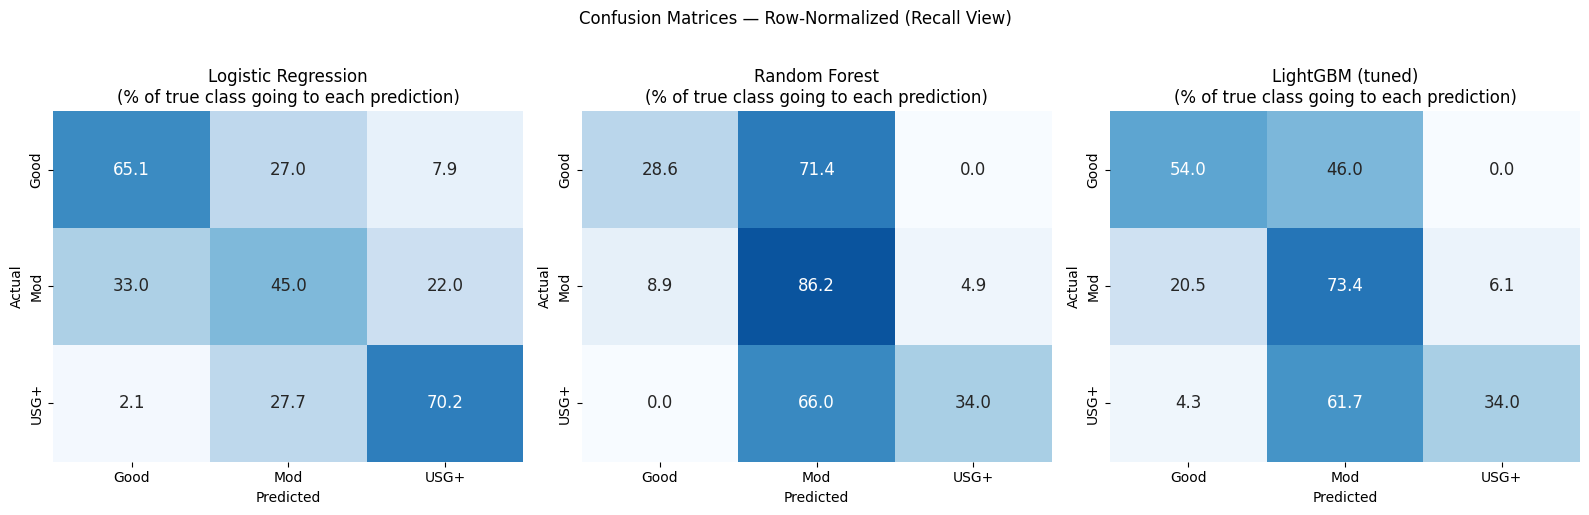

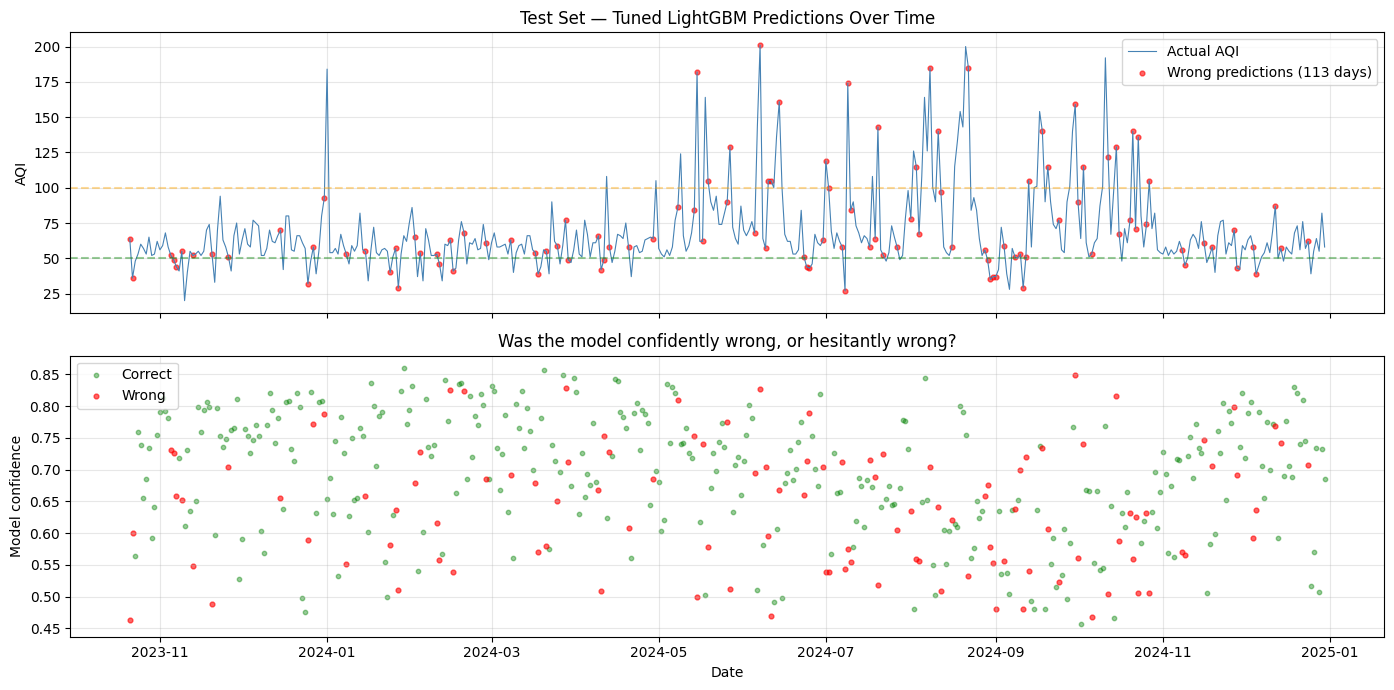

📏 ERROR MAGNITUDE — How far off are wrong predictions?
   Correct                  :  324 days ( 74.1%)
   Off by 1 class           :  112 days ( 25.6%)
   Off by 2 classes         :    1 days (  0.2%)

🚨 CLASS 2 (USG+) DEEP DIVE — public health critical
Total true USG+ days in test: 47
Caught (predicted USG+):      26 (55.3%)
Missed as Moderate:           21 (44.7%)
Missed as Good:               0 (0.0%)

Total USG+ predictions made: 56
Were truly USG+:              26 (46.4%)
Were truly Moderate:          29 (51.8%)
Were truly Good:              1 (1.8%)

📋 FINAL DIAGNOSTIC SUMMARY
              Model  Accuracy  Macro F1  Recall (Good)  Recall (Mod)  Recall (USG+)  Precision (USG+)
Logistic Regression     0.506     0.463          0.651         0.450          0.702             0.300
      Random Forest     0.723     0.519          0.286         0.862          0.340             0.500
   LightGBM (tuned)     0.664     0.521          0.540         0.734          0.340             0.444


In [75]:
# ============================================================
# DIAGNOSTIC REVIEW: Understanding the model deeply before deployment
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support,
    f1_score
)

CLASS_NAMES = ["Good (≤50)", "Moderate (51-100)", "USG+ (>100)"]

# We'll focus on the tuned LightGBM (our current "production" candidate)
# but include all three for context
final_models = {
    "Logistic Regression": trained["Logistic Regression"],
    "Random Forest":       trained["Random Forest"],
    "LightGBM (tuned)":    trained["LightGBM"],
}


# ----------------------------------------------------------------
# DIAGNOSTIC 1: Side-by-side confusion matrices, normalized by row
# ----------------------------------------------------------------
# Shows: "Of the days that were truly Class X, what % did the model predict as each class?"
# This is the RECALL view — most useful for an alert system.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, final_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=["Good", "Mod", "USG+"],
                yticklabels=["Good", "Mod", "USG+"],
                ax=ax, cbar=False, vmin=0, vmax=100,
                annot_kws={"size": 12})
    ax.set_title(f"{name}\n(% of true class going to each prediction)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Row-Normalized (Recall View)", y=1.02)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------
# DIAGNOSTIC 2: Where exactly are the errors happening over time?
# ----------------------------------------------------------------
# A line plot of true vs predicted on the test set, with errors highlighted.
# This reveals whether errors are random or clustered (e.g., always wrong
# during a specific season or event).

best_model = rf_final
y_pred = y_pred_final
y_pred_proba = rf_final.predict_proba(X_test)

# Reconstruct the test dataframe with predictions
test_view = test_df[["date", "AQI", "target"]].copy().reset_index(drop=True)
test_view["predicted"] = y_pred
test_view["correct"] = (test_view["target"] == test_view["predicted"]).astype(int)
test_view["confidence"] = y_pred_proba.max(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top plot: AQI over time, with errors marked
axes[0].plot(test_view["date"], test_view["AQI"],
             color="steelblue", linewidth=0.8, label="Actual AQI")
axes[0].axhline(50, color="green",  linestyle="--", alpha=0.4)
axes[0].axhline(100, color="orange", linestyle="--", alpha=0.4)
errors = test_view[test_view["correct"] == 0]
axes[0].scatter(errors["date"], errors["AQI"],
                color="red", s=12, alpha=0.6,
                label=f"Wrong predictions ({len(errors)} days)")
axes[0].set_ylabel("AQI")
axes[0].set_title(f"Test Set — Tuned LightGBM Predictions Over Time")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

# Bottom plot: confidence on errors vs correct
axes[1].scatter(test_view[test_view.correct==1]["date"],
                test_view[test_view.correct==1]["confidence"],
                color="green", alpha=0.4, s=10, label="Correct")
axes[1].scatter(test_view[test_view.correct==0]["date"],
                test_view[test_view.correct==0]["confidence"],
                color="red", alpha=0.6, s=12, label="Wrong")
axes[1].set_ylabel("Model confidence")
axes[1].set_xlabel("Date")
axes[1].set_title("Was the model confidently wrong, or hesitantly wrong?")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------
# DIAGNOSTIC 3: What KIND of errors are we making?
# ----------------------------------------------------------------
# Are wrong predictions off by 1 class (Good→Mod, Mod→USG+) or by 2 (Good→USG+)?
# 1-class errors are forgivable — they're near the boundary.
# 2-class errors are bad — model is fundamentally confused.

test_view["error_magnitude"] = (test_view["predicted"] - test_view["target"]).abs()
print("="*60)
print("📏 ERROR MAGNITUDE — How far off are wrong predictions?")
print("="*60)
mag = test_view["error_magnitude"].value_counts().sort_index()
for m, n in mag.items():
    label = {0: "Correct", 1: "Off by 1 class", 2: "Off by 2 classes"}[m]
    pct = n / len(test_view) * 100
    print(f"   {label:25s}: {n:4d} days ({pct:5.1f}%)")

# Class 2 deep-dive: when we miss an unhealthy day, what do we say instead?
print("\n" + "="*60)
print("🚨 CLASS 2 (USG+) DEEP DIVE — public health critical")
print("="*60)
true_usg = test_view[test_view["target"] == 2]
print(f"Total true USG+ days in test: {len(true_usg)}")
print(f"Caught (predicted USG+):      {(true_usg['predicted'] == 2).sum()} "
      f"({(true_usg['predicted'] == 2).mean()*100:.1f}%)")
print(f"Missed as Moderate:           {(true_usg['predicted'] == 1).sum()} "
      f"({(true_usg['predicted'] == 1).mean()*100:.1f}%)")
print(f"Missed as Good:               {(true_usg['predicted'] == 0).sum()} "
      f"({(true_usg['predicted'] == 0).mean()*100:.1f}%)")

# Reverse: when we predict USG+, how often is it real?
pred_usg = test_view[test_view["predicted"] == 2]
print(f"\nTotal USG+ predictions made: {len(pred_usg)}")
if len(pred_usg) > 0:
    print(f"Were truly USG+:              {(pred_usg['target'] == 2).sum()} "
          f"({(pred_usg['target'] == 2).mean()*100:.1f}%)")
    print(f"Were truly Moderate:          {(pred_usg['target'] == 1).sum()} "
          f"({(pred_usg['target'] == 1).mean()*100:.1f}%)")
    print(f"Were truly Good:              {(pred_usg['target'] == 0).sum()} "
          f"({(pred_usg['target'] == 0).mean()*100:.1f}%)")


# ----------------------------------------------------------------
# DIAGNOSTIC 4: Final cheat-sheet table
# ----------------------------------------------------------------
print("\n" + "="*60)
print("📋 FINAL DIAGNOSTIC SUMMARY")
print("="*60)

rows = []
for name, model in final_models.items():
    yp = model.predict(X_test)
    p, r, f, _ = precision_recall_fscore_support(y_test, yp, zero_division=0)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, yp),
        "Macro F1": f1_score(y_test, yp, average="macro"),
        "Recall (Good)": r[0],
        "Recall (Mod)":  r[1],
        "Recall (USG+)": r[2],
        "Precision (USG+)": p[2],
    })

summary = pd.DataFrame(rows)
# Pretty-print
for col in summary.columns[1:]:
    summary[col] = summary[col].round(3)
print(summary.to_string(index=False))

Most errors are off by one class and occur near AQI thresholds, while USG+ detection improves but still includes some false positives.

In [76]:
# Verify final Random Forest model performance

print("Final Model: Random Forest + Threshold 0.40")
print("Train accuracy:", rf_final.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_final))
print("Macro F1:", f1_score(y_test, y_pred_final, average="macro"))
print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

Final Model: Random Forest + Threshold 0.40
Train accuracy: 0.7847738981110475
Test accuracy: 0.7414187643020596
Macro F1: 0.4858434750900223
                   precision    recall  f1-score   support

       Good (≤50)       0.50      0.06      0.11        63
Moderate (51-100)       0.79      0.90      0.84       327
      USG+ (>100)       0.46      0.55      0.50        47

         accuracy                           0.74       437
        macro avg       0.58      0.51      0.49       437
     weighted avg       0.71      0.74      0.70       437



The final model achieves strong overall performance while improving detection of USG+ days, making it suitable for real-world AQI alerting.

## Model Saving

Saved the trained model and required metadata for reuse and deployment.

In [77]:
# ============================================================
# STEP 9A: SAVE THE FINAL MODEL AND METADATA
# ============================================================

import joblib
import json
from pathlib import Path

MODEL_DIR = Path("/content/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save final Random Forest model
MODEL_PATH = MODEL_DIR / "rf_final_aqi.pkl"
joblib.dump(rf_final, MODEL_PATH)

print(f"Model saved: {MODEL_PATH} ({MODEL_PATH.stat().st_size/1024:.1f} KB)")

# Save feature schema and threshold
SCHEMA_PATH = MODEL_DIR / "feature_schema.json"

schema = {
    "feature_columns": list(feature_cols),
    "class_names": ["Good", "Moderate", "USG+"],
    "class_descriptions": {
        "0": "Good (AQI ≤ 50) — air quality is satisfactory",
        "1": "Moderate (AQI 51-100) — acceptable for most",
        "2": "USG+ (AQI > 100) — sensitive individuals should reduce exertion",
    },
    "threshold": 0.40,
    "training_date_range": [
        str(df_feat["date"].min().date()),
        str(df_feat["date"].max().date()),
    ],
    "n_features": len(feature_cols),
}

with open(SCHEMA_PATH, "w") as f:
    json.dump(schema, f, indent=2)

print(f"Schema saved: {SCHEMA_PATH}")
print(f"Features expected: {schema['n_features']}")
print(f"USG+ threshold: {schema['threshold']}")

Model saved: /content/models/rf_final_aqi.pkl (5343.7 KB)
Schema saved: /content/models/feature_schema.json
Features expected: 31
USG+ threshold: 0.4


The final Random Forest model and feature schema were saved successfully for reuse during prediction and deployment.

## Prediction Pipeline

Built a reusable function to generate next-day AQI predictions using recent data and the trained model.

In [78]:
# ============================================================
# STEP 9B: PREDICTION FUNCTION
# ============================================================

import pandas as pd
import numpy as np
import joblib
import json
from typing import Dict, Any
from pathlib import Path


def load_artifacts(model_dir: str = "/content/models"):
    """Load final model and feature schema from disk."""
    model_dir = Path(model_dir)
    model = joblib.load(model_dir / "rf_final_aqi.pkl")

    with open(model_dir / "feature_schema.json") as f:
        schema = json.load(f)

    return model, schema


def build_features_for_prediction(recent_data: pd.DataFrame) -> pd.DataFrame:
    """
    Rebuild the same features used during training.
    Requires at least 8 recent days of data.
    """
    df = recent_data.copy().sort_values("date").reset_index(drop=True)

    # Lag features
    df["AQI_lag_1"] = df["AQI"].shift(1)
    df["AQI_lag_2"] = df["AQI"].shift(2)
    df["AQI_lag_7"] = df["AQI"].shift(7)

    # Trend/change features
    df["AQI_diff_1"] = df["AQI"] - df["AQI"].shift(1)
    df["AQI_diff_2"] = df["AQI"] - df["AQI"].shift(2)
    df["AQI_diff_7"] = df["AQI"] - df["AQI"].shift(7)

    df["AQI_rising_1"] = (df["AQI_diff_1"] > 0).astype(int)
    df["AQI_rising_2"] = (df["AQI_diff_2"] > 0).astype(int)
    df["AQI_rising_7"] = (df["AQI_diff_7"] > 0).astype(int)

    df["AQI_momentum_3"] = (
        (df["AQI"].shift(1) > df["AQI"].shift(2)) &
        (df["AQI"].shift(2) > df["AQI"].shift(3))
    ).astype(int)

    # Rolling features
    df["AQI_ma_3"] = df["AQI"].shift(1).rolling(3).mean()
    df["AQI_ma_7"] = df["AQI"].shift(1).rolling(7).mean()
    df["AQI_std_7"] = df["AQI"].shift(1).rolling(7).std()

    # Weather features
    df["temp_x_lowwind"] = df["temperature"] * (1 / (df["wind_speed"] + 1))
    df["temperature_lag_1"] = df["temperature"].shift(1)
    df["humidity_lag_1"] = df["humidity"].shift(1)
    df["wind_speed_lag_1"] = df["wind_speed"].shift(1)

    # Time features
    df["day_of_week"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["day_of_year"] = df["date"].dt.dayofyear
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Pollutant one-hot features
    df["defining_parameter_lag_1"] = df["defining_parameter"].shift(1)

    for poll in ["NO2", "Ozone", "PM10", "PM2.5"]:
        col = f"poll_yday_{poll}"
        df[col] = (df["defining_parameter_lag_1"] == poll).astype(int)

    return df


def predict_next_day_aqi(
    recent_data: pd.DataFrame,
    model=None,
    schema=None
) -> Dict[str, Any]:
    """
    Predict next-day AQI category using the final saved model.
    """

    if model is None or schema is None:
        model, schema = load_artifacts()

    required_cols = {
        "date", "AQI", "defining_parameter",
        "temperature", "humidity", "wind_speed", "precipitation"
    }

    missing = required_cols - set(recent_data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if len(recent_data) < 8:
        raise ValueError(f"Need at least 8 days of recent data; got {len(recent_data)}")

    df = recent_data.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)

    feat_df = build_features_for_prediction(df)

    last_row = feat_df.iloc[[-1]]

    expected_cols = schema["feature_columns"]

    missing_features = set(expected_cols) - set(last_row.columns)
    if missing_features:
        raise ValueError(f"Feature engineering missed columns: {missing_features}")

    X_pred = last_row[expected_cols]

    if X_pred.isna().any().any():
        nan_cols = X_pred.columns[X_pred.isna().any()].tolist()
        raise ValueError(f"Got NaN in features: {nan_cols}")

    proba = model.predict_proba(X_pred)[0]

    threshold = schema["threshold"]

    pred_class = int(np.argmax(proba))

    # Apply final USG+ threshold
    if proba[2] >= threshold:
        pred_class = 2

    based_on = df["date"].iloc[-1]

    return {
        "prediction_for_date": (based_on + pd.Timedelta(days=1)).date().isoformat(),
        "based_on_date": based_on.date().isoformat(),
        "predicted_class": pred_class,
        "predicted_label": schema["class_names"][pred_class],
        "predicted_description": schema["class_descriptions"][str(pred_class)],
        "probabilities": {
            schema["class_names"][i]: float(proba[i]) for i in range(3)
        },
        "confidence": float(proba.max()),
        "threshold_used": threshold,
        "latest_actual_aqi": float(df["AQI"].iloc[-1])
    }

The prediction function reconstructs training features and ensures consistent, reliable predictions on new data.

In [79]:
# ============================================================
# STEP 9C: TEST THE PREDICTION FUNCTION
# ============================================================
import pprint

# Take the last 30 days of raw data (we need at least 8, but more is fine)
recent_window = df.tail(30).copy()   # 'df' = the cleaned merged dataframe from Step 2

print(f"Using {len(recent_window)} recent days, ending {recent_window['date'].max().date()}")
print(f"Predicting for the day AFTER that.\n")

# Run the prediction
result = predict_next_day_aqi(recent_window)

print("="*60)
print("🌫️  AQI PREDICTION RESULT")
print("="*60)
pprint.pprint(result, sort_dicts=False)

# Pretty-print the probability bar
print("\n📊 Probability distribution:")
for label, prob in result["probabilities"].items():
    bar = "█" * int(prob * 40)
    print(f"   {label:10s} {prob*100:5.1f}% {bar}")

print(f"\n🎯 Confidence: {result['confidence']*100:.1f}%")
print(f"📅 Predicting for: {result['prediction_for_date']}")
print(f"📌 Based on data through: {result['based_on_date']}")
print(f"Threshold used: {result['threshold_used']}")
print(f"Latest actual AQI: {result['latest_actual_aqi']}")

Using 30 recent days, ending 2024-12-31
Predicting for the day AFTER that.

🌫️  AQI PREDICTION RESULT
{'prediction_for_date': '2025-01-01',
 'based_on_date': '2024-12-31',
 'predicted_class': 1,
 'predicted_label': 'Moderate',
 'predicted_description': 'Moderate (AQI 51-100) — acceptable for most',
 'probabilities': {'Good': 0.1612563478821207,
                   'Moderate': 0.761249542629362,
                   'USG+': 0.07749410948851734},
 'confidence': 0.761249542629362,
 'threshold_used': 0.4,
 'latest_actual_aqi': 71.0}

📊 Probability distribution:
   Good        16.1% ██████
   Moderate    76.1% ██████████████████████████████
   USG+         7.7% ███

🎯 Confidence: 76.1%
📅 Predicting for: 2025-01-01
📌 Based on data through: 2024-12-31
Threshold used: 0.4
Latest actual AQI: 71.0


The prediction function successfully generates the next-day AQI category, probability distribution, confidence score, and threshold used.

In [81]:
# ============================================================
# 9D. BACKTEST: simulate running this daily on the last 14 days
# ============================================================
print("\n" + "="*70)
print("📅 14-DAY BACKTEST — if we had been predicting daily")
print("="*70)
print(f"{'Pred for':<12} {'Predicted':<12} {'Actual':<12} {'Conf':<8} {'Thresh':<10}")
print("-"*70)

# Loop: for each of the last 14 days, use the 30 days BEFORE it as history
for i in range(14, 0, -1):
    # 'today' is i days before the end of our data
    end_idx = len(df) - i
    history = df.iloc[max(0, end_idx-30):end_idx + 1].copy()  # last 30 days through 'today'

    if len(history) < 8:
        continue

    pred = predict_next_day_aqi(history)

    # What was actually observed the next day?
    actual_idx = end_idx + 1
    if actual_idx < len(df):
        actual_aqi = df.iloc[actual_idx]["AQI"]
        actual_class = aqi_to_class(actual_aqi)
        actual_label = ["Good", "Moderate", "USG+"][actual_class]
        match = "✓" if pred["predicted_class"] == actual_class else "✗"
    else:
        actual_label = "?"
        match = "?"

    print(f"{pred['prediction_for_date']:<12} "
          f"{pred['predicted_label']:<12} "
          f"{actual_label:<10}{match} "
          f"{pred['confidence']*100:>5.1f}% "
          f"{pred['threshold_used']:<10}")


📅 14-DAY BACKTEST — if we had been predicting daily
Pred for     Predicted    Actual       Conf     Thresh    
----------------------------------------------------------------------
2024-12-19   Moderate     Moderate  ✓  68.9% 0.4       
2024-12-20   Moderate     Moderate  ✓  83.0% 0.4       
2024-12-21   Moderate     Moderate  ✓  82.0% 0.4       
2024-12-22   Moderate     Moderate  ✓  74.0% 0.4       
2024-12-23   Moderate     Moderate  ✓  81.0% 0.4       
2024-12-24   Moderate     Moderate  ✓  74.5% 0.4       
2024-12-25   Moderate     Good      ✗  70.8% 0.4       
2024-12-26   Moderate     Moderate  ✓  51.8% 0.4       
2024-12-27   Moderate     Moderate  ✓  57.1% 0.4       
2024-12-28   Moderate     Moderate  ✓  73.5% 0.4       
2024-12-29   Moderate     Moderate  ✓  50.7% 0.4       
2024-12-30   Moderate     Moderate  ✓  73.2% 0.4       
2024-12-31   Moderate     Moderate  ✓  68.6% 0.4       
2025-01-01   Moderate     ?         ?  76.1% 0.4       


The backtest shows consistent performance over recent days, validating the model’s real-world usability.

## Hyperparameter Tuning Setup

Set up time-series cross-validation and macro F1 scoring to tune models while preserving chronological order.

In [82]:
# ============================================================
# TUNING SETUP
# ============================================================
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, precision_recall_fscore_support
)
import lightgbm as lgb
import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
import time

# Time-series CV — 5 expanding-window folds.
# Critical: this respects chronology, unlike random K-fold.
tscv = TimeSeriesSplit(n_splits=5)
SCORING = "f1_macro"

print("✅ Setup complete. Using TimeSeriesSplit(n_splits=5) and scoring='f1_macro'")

✅ Setup complete. Using TimeSeriesSplit(n_splits=5) and scoring='f1_macro'


## Random Forest Hyperparameter Tuning

Used RandomizedSearchCV with TimeSeriesSplit to tune Random Forest parameters while keeping the time order intact.

In [83]:
# ============================================================
# RANDOM FOREST — RandomizedSearchCV
# ============================================================
rf_param_dist = {
    "n_estimators":     randint(200, 800),
    "max_depth":        [None, 8, 12, 16, 20, 25],
    "min_samples_split":randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features":     ["sqrt", "log2", 0.5],
    "class_weight":     ["balanced", "balanced_subsample"],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=40,
    cv=tscv,
    scoring=SCORING,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print("🔍 Tuning Random Forest (3-5 minutes)...")
t0 = time.time()
rf_search.fit(X_train, y_train)
print(f"⏱️  Done in {time.time()-t0:.0f}s")

print(f"\n✅ Best params:")
for k, v in rf_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"\n   Best CV macro F1: {rf_search.best_score_:.3f}")
print(f"   (Original RF macro F1 was 0.529)")

# Evaluate on test set
rf_best = rf_search.best_estimator_
y_pred_rf = rf_best.predict(X_test)
print(f"\n📊 Tuned RF on TEST set:")
print(f"   Accuracy: {rf_best.score(X_test, y_test):.3f}")
print(f"   Macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.3f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['Good','Moderate','USG+'], digits=3))

🔍 Tuning Random Forest (3-5 minutes)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
⏱️  Done in 422s

✅ Best params:
   class_weight: balanced
   max_depth: None
   max_features: sqrt
   min_samples_leaf: 9
   min_samples_split: 14
   n_estimators: 458

   Best CV macro F1: 0.530
   (Original RF macro F1 was 0.529)

📊 Tuned RF on TEST set:
   Accuracy: 0.680
   Macro F1: 0.567
              precision    recall  f1-score   support

        Good      0.372     0.508     0.430        63
    Moderate      0.832     0.725     0.775       327
        USG+      0.424     0.596     0.496        47

    accuracy                          0.680       437
   macro avg      0.543     0.609     0.567       437
weighted avg      0.722     0.680     0.695       437



RandomizedSearchCV improved macro F1 and minority class recall, but reduced overall accuracy. The final model instead uses a regularized Random Forest with threshold tuning to better balance real-world performance and risk detection.

## (Optional) LightGBM Advanced Tuning — Not Used in Final Model

This section was explored but not included in the final model, as Random Forest with threshold tuning provided a better balance of performance.

In [84]:
# ============================================================
# LIGHTGBM — RandomizedSearchCV (COMMENTED OUT)
# ============================================================

# This section was explored but not used in the final model.
# Random Forest + threshold tuning provided a better balance.

# lgbm_param_dist = {
#     "num_leaves":         randint(15, 80),
#     "max_depth":          [-1, 6, 8, 10, 12],
#     "learning_rate":      uniform(0.01, 0.15),
#     "n_estimators":       randint(200, 800),
#     "min_child_samples":  randint(10, 60),
#     "subsample":          uniform(0.7, 0.3),
#     "colsample_bytree":   uniform(0.7, 0.3),
#     "reg_alpha":          uniform(0, 1.0),
#     "reg_lambda":         uniform(0, 1.0),
#     "class_weight":       ["balanced"],
# }

# lgbm_search = RandomizedSearchCV(
#     estimator=lgb.LGBMClassifier(
#         objective="multiclass",
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1,
#     ),
#     param_distributions=lgbm_param_dist,
#     n_iter=50,
#     cv=tscv,
#     scoring=SCORING,
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
# )

# print("Tuning LightGBM (3-5 minutes)...")
# t0 = time.time()
# lgbm_search.fit(X_train, y_train)
# print(f"Done in {time.time()-t0:.0f}s")

# print("\nBest params:")
# for k, v in lgbm_search.best_params_.items():
#     if isinstance(v, float):
#         print(f"   {k}: {v:.4f}")
#     else:
#         print(f"   {k}: {v}")

# print(f"\nBest CV macro F1: {lgbm_search.best_score_:.3f}")

# # Evaluate on test set
# lgbm_best = lgbm_search.best_estimator_
# y_pred_lgbm = lgbm_best.predict(X_test)

# print("\nTuned LightGBM on TEST set:")
# print(f"Accuracy: {lgbm_best.score(X_test, y_test):.3f}")
# print(f"Macro F1: {f1_score(y_test, y_pred_lgbm, average='macro'):.3f}")

# print(classification_report(
#     y_test, y_pred_lgbm,
#     target_names=['Good','Moderate','USG+'],
#     digits=3
# ))

## (Optional) Model Comparison After Tuning — Not Used in Final Selection

This section compares tuned models, but the final model was selected based on threshold tuning and real-world performance considerations rather than automated selection.

In [85]:
# ============================================================
# COMPARISON: before vs after tuning (COMMENTED OUT)
# ============================================================

# versions = {
#     "Random Forest (original)":     trained["Random Forest"],
#     "Random Forest (tuned)":        rf_best,
#     "LightGBM (Step 7 tuned)":      trained["LightGBM"],
#     "LightGBM (RandSearch tuned)":  lgbm_best,
# }

# rows = []
# for name, model in versions.items():
#     yp = model.predict(X_test)
#     p, r, f, _ = precision_recall_fscore_support(y_test, yp, zero_division=0)
#     rows.append({
#         "Model":        name,
#         "Accuracy":     round(accuracy_score(y_test, yp), 3),
#         "Macro F1":     round(f1_score(y_test, yp, average="macro"), 3),
#         "USG+ Recall":  round(r[2], 3),
#         "USG+ F1":      round(f[2], 3),
#     })

# print("\n" + "="*70)
# print("BEFORE vs AFTER TUNING")
# print("="*70)
# print(pd.DataFrame(rows).to_string(index=False))

# # Promote the winners (NOT USED in final model selection)
# if f1_score(y_test, lgbm_best.predict(X_test), average="macro") > \
#    f1_score(y_test, trained["LightGBM"].predict(X_test), average="macro"):
#     print("\nPromoting RandSearch-tuned LightGBM")
#     trained["LightGBM"] = lgbm_best

# if f1_score(y_test, rf_best.predict(X_test), average="macro") > \
#    f1_score(y_test, trained["Random Forest"].predict(X_test), average="macro"):
#     print("Promoting tuned Random Forest")
#     trained["Random Forest"] = rf_best

## (Duplicated Code) - Please do not consider this

## Train-Test Split

Generated features and split the dataset into training and testing sets using a time-based split.

In [86]:
# df_feat = build_features(df)

# EXCLUDE = {
#     "date", "AQI", "AQI_next", "target",
#     "defining_parameter", "defining_parameter_lag_1"
# }

# feature_cols = [c for c in df_feat.columns if c not in EXCLUDE]

# X_train, X_test, y_train, y_test, train_df, test_df = time_based_split(
#     df_feat, feature_cols, target_col="target", train_frac=0.80
# )

In [87]:
# from sklearn.ensemble import RandomForestClassifier

# rf_final = RandomForestClassifier(
#     n_estimators=500,
#     max_depth=8,
#     min_samples_leaf=8,
#     max_features="sqrt",
#     class_weight={0: 1, 1: 1, 2: 4},
#     random_state=42,
#     n_jobs=-1
# )

# rf_final.fit(X_train, y_train)

# print("Train accuracy:", rf_final.score(X_train, y_train))
# print("Test accuracy:", rf_final.score(X_test, y_test))

In [88]:
# from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score

# CLASS_NAMES = ["Good (≤50)", "Moderate (51-100)", "USG+ (>100)"]

# y_pred = rf_final.predict(X_test)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Macro F1:", f1_score(y_test, y_pred, average="macro"))

# print("\nFull Report:")
# print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

In [89]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score

# probs = rf_final.predict_proba(X_test)

# results = []

# for threshold in [0.15, 0.20, 0.25, 0.30, 0.35, 0.40]:
#     y_pred_custom = np.argmax(probs, axis=1)

#     # Force USG+ prediction if probability crosses threshold
#     y_pred_custom[probs[:, 2] >= threshold] = 2

#     acc = accuracy_score(y_test, y_pred_custom)
#     macro_f1 = f1_score(y_test, y_pred_custom, average="macro")
#     usg_recall = recall_score(y_test, y_pred_custom, labels=[2], average=None)[0]
#     usg_f1 = f1_score(y_test, y_pred_custom, labels=[2], average=None)[0]

#     results.append({
#         "threshold": threshold,
#         "accuracy": acc,
#         "macro_f1": macro_f1,
#         "USG+ recall": usg_recall,
#         "USG+ f1": usg_f1
#     })

# df_results = pd.DataFrame(results)
# print(df_results)

In [90]:
# best_threshold = 0.25

# y_pred_final = np.argmax(probs, axis=1)
# y_pred_final[probs[:, 2] >= best_threshold] = 2

# from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score

# print("Final Model (Threshold = 0.25)")
# print("Accuracy:", accuracy_score(y_test, y_pred_final))
# print("Macro F1:", f1_score(y_test, y_pred_final, average="macro"))
# print(classification_report(y_test, y_pred_final, target_names=CLASS_NAMES))

## Download Important Files to import into Streamlit

In [91]:
from google.colab import files
files.download('/content/models/rf_final_aqi.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
files.download('/content/models/feature_schema.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [94]:
df.to_csv('/content/recent_aqi_data.csv', index=False)

In [95]:
import os
os.path.exists('/content/recent_aqi_data.csv')

True

In [96]:
from google.colab import files
files.download('/content/recent_aqi_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>